
 PERCEPTRON TRAINING 
Epoch 1: Weights = [0.1 0.1], Bias = 0.10, Errors = 1
Epoch 2: Weights = [0.2 0.1], Bias = 0.00, Errors = 3
Epoch 3: Weights = [0.2 0.1], Bias = -0.10, Errors = 3
Epoch 4: Weights = [0.2 0.2], Bias = -0.10, Errors = 2
Epoch 5: Weights = [0.2 0.1], Bias = -0.20, Errors = 1
Epoch 6: Weights = [0.2 0.1], Bias = -0.20, Errors = 0

Perceptron converged!
Converged after 6 epochs.

 FINAL PERCEPTRON PARAMETERS 
Weight 1: 0.2
Weight 2: 0.1
Bias: -0.2

AND GATE PREDICTION
Using X1 = 1.0, X2 = 1.0 for prediction.

Weighted Sum: 0.10000000000000003
Predicted Output: 1


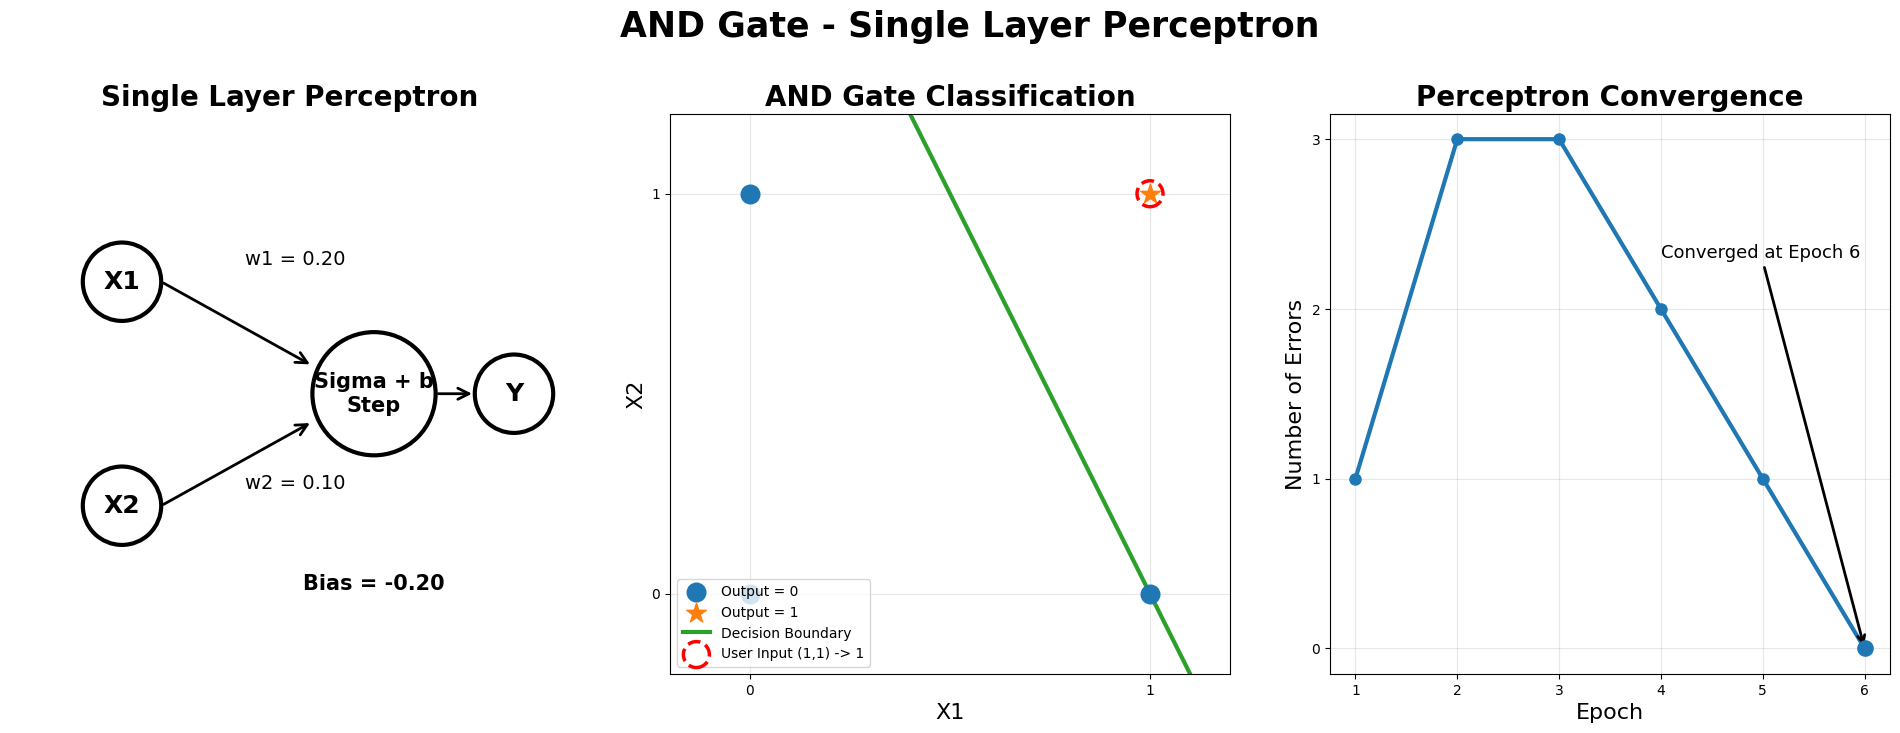

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# =========================================================
# 1. AND GATE TRAINING DATA
# =========================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 0, 0, 1])


# =========================================================
# 2. INITIALIZE WEIGHTS AND BIAS
# =========================================================

weights = np.array([0.0, 0.0])
bias = 0.0

learning_rate = 0.1
max_epochs = 100


# =========================================================
# 3. STEP ACTIVATION FUNCTION
# =========================================================

def activation(z):
    if z > 0:
        return 1
    else:
        return 0


# =========================================================
# 4. PERCEPTRON TRAINING
# =========================================================

error_history = []

print("\n==============================")
print(" PERCEPTRON TRAINING ")
print("==============================")

for epoch in range(max_epochs):

    errors = 0

    for i in range(len(X)):

        z = np.dot(X[i], weights) + bias

        prediction = activation(z)

        error = y[i] - prediction

        if error != 0:
            weights = weights + \
                learning_rate * error * X[i]

            bias = bias + learning_rate * error

            errors += 1

    error_history.append(errors)

    print(
        f"Epoch {epoch + 1}: "
        f"Weights = {weights}, "
        f"Bias = {bias:.2f}, "
        f"Errors = {errors}"
    )

    if errors == 0:
        print("\nPerceptron converged!")
        print(
            f"Converged after {epoch + 1} epochs."
        )
        break

else:
    print(
        "\nPerceptron did not converge "
        "within the maximum epochs."
    )


# =========================================================
# 5. FINAL PARAMETERS
# =========================================================

print("\n==============================")
print(" FINAL PERCEPTRON PARAMETERS ")
print("==============================")

print("Weight 1:", weights[0])
print("Weight 2:", weights[1])
print("Bias:", bias)


# =========================================================
# 6. USER INPUT (MODIFIED FOR DEMONSTRATION)
# =========================================================

print("\n==============================")
print("AND GATE PREDICTION")
print("==============================")

# Original code:
# while True:
#     try:
#         x1 = float(input("Enter X1 (0 or 1): "))
#         x2 = float(input("Enter X2 (0 or 1): "))
#         if x1 in [0, 1] and x2 in [0, 1]:
#             break
#         print("Please enter only 0 or 1.")
#     except ValueError:
#         print("Invalid input.")

# Modified for programmatic input:
x1 = 1.0
x2 = 1.0
print(f"Using X1 = {x1}, X2 = {x2} for prediction.")


# =========================================================
# 7. USER PREDICTION
# =========================================================

user_input = np.array([x1, x2])

z_user = np.dot(user_input, weights) + bias

user_prediction = activation(z_user)

print("\nWeighted Sum:", z_user)
print("Predicted Output:", user_prediction)


# =========================================================
# 8. CREATE FIGURE
# =========================================================

fig = plt.figure(figsize=(20, 8))


# =========================================================
# 9. PERCEPTRON ARCHITECTURE
# =========================================================

ax1 = fig.add_axes([0.02, 0.15, 0.28, 0.70])

ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis("off")

ax1.set_title(
    "Single Layer Perceptron",
    fontsize=20,
    fontweight="bold"
)

input_positions = [(2, 7), (2, 3)]
input_labels = ["X1", "X2"]

for (x, y_pos), label in zip(
    input_positions, input_labels
):

    circle = Circle(
        (x, y_pos),
        0.7,
        fill=False,
        linewidth=3
    )

    ax1.add_patch(circle)

    ax1.text(
        x,
        y_pos,
        label,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold"
    )

ax1.text(
    4.2,
    7.3,
    f"w1 = {weights[0]:.2f}",
    fontsize=14
)

ax1.text(
    4.2,
    3.3,
    f"w2 = {weights[1]:.2f}",
    fontsize=14
)

neuron = Circle(
    (6.5, 5),
    1.1,
    fill=False,
    linewidth=3
)

ax1.add_patch(neuron)

ax1.text(
    6.5,
    5,
    "Sigma + b\nStep",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

output = Circle(
    (9, 5),
    0.7,
    fill=False,
    linewidth=3
)

ax1.add_patch(output)

ax1.text(
    9,
    5,
    "Y",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

arrow1 = FancyArrowPatch(
    (2.7, 7),
    (5.4, 5.5),
    arrowstyle="->",
    mutation_scale=20,
    linewidth=2
)

arrow2 = FancyArrowPatch(
    (2.7, 3),
    (5.4, 4.5),
    arrowstyle="->",
    mutation_scale=20,
    linewidth=2
)

arrow3 = FancyArrowPatch(
    (7.6, 5),
    (8.3, 5),
    arrowstyle="->",
    mutation_scale=20,
    linewidth=2
)

ax1.add_patch(arrow1)
ax1.add_patch(arrow2)
ax1.add_patch(arrow3)

ax1.text(
    6.5,
    1.5,
    f"Bias = {bias:.2f}",
    ha="center",
    fontsize=15,
    fontweight="bold"
)


# =========================================================
# 10. AND GATE CLASSIFICATION
# =========================================================

ax2 = fig.add_axes([0.35, 0.15, 0.28, 0.70])

class_0 = X[y == 0]
class_1 = X[y == 1]

ax2.scatter(
    class_0[:, 0],
    class_0[:, 1],
    s=180,
    marker="o",
    label="Output = 0",
    zorder=3
)

ax2.scatter(
    class_1[:, 0],
    class_1[:, 1],
    s=220,
    marker="*",
    label="Output = 1",
    zorder=3
)


# =========================================================
# 11. DECISION BOUNDARY
# =========================================================

x_boundary = np.linspace(-0.2, 1.2, 100)

if abs(weights[1]) > 1e-10:

    y_boundary = (
        -(weights[0] * x_boundary + bias)
        / weights[1]
    )

    ax2.plot(
        x_boundary,
        y_boundary,
        linewidth=3,
        label="Decision Boundary",
        color="tab:green",
        zorder=2
    )

elif abs(weights[0]) > 1e-10:

    x_vertical = -bias / weights[0]

    ax2.axvline(
        x=x_vertical,
        linewidth=3,
        label="Decision Boundary",
        color="tab:green",
        zorder=2
    )


# =========================================================
# 12. USER INPUT
# =========================================================

ax2.scatter(
    x1,
    x2,
    s=350,
    facecolors="none",
    edgecolors="red",
    linewidths=2.5,
    linestyle="--",
    label=f"User Input ({x1:.0f},{x2:.0f}) -> "
          f"{user_prediction}",
    zorder=4
)

ax2.set_title(
    "AND Gate Classification",
    fontsize=20,
    fontweight="bold"
)

ax2.set_xlabel("X1", fontsize=16)
ax2.set_ylabel("X2", fontsize=16)

ax2.set_xlim(-0.2, 1.2)
ax2.set_ylim(-0.2, 1.2)

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])

ax2.grid(True, alpha=0.3)

ax2.legend(
    fontsize=10,
    loc="lower left"
)


# =========================================================
# 13. CONVERGENCE GRAPH
# =========================================================

ax3 = fig.add_axes([0.68, 0.15, 0.28, 0.70])

epochs = np.arange(
    1,
    len(error_history) + 1
)

ax3.plot(
    epochs,
    error_history,
    marker="o",
    linewidth=3,
    markersize=8
)

ax3.set_title(
    "Perceptron Convergence",
    fontsize=20,
    fontweight="bold"
)

ax3.set_xlabel(
    "Epoch",
    fontsize=16
)

ax3.set_ylabel(
    "Number of Errors",
    fontsize=16
)

ax3.set_xticks(epochs)

ax3.set_yticks(
    range(
        0,
        max(error_history) + 1
    )
)

ax3.grid(
    True,
    alpha=0.3
)


# =========================================================
# 14. MARK CONVERGENCE POINT
# =========================================================

if error_history[-1] == 0:

    convergence_epoch = len(error_history)

    ax3.scatter(
        convergence_epoch,
        0,
        s=120,
        zorder=5
    )

    ax3.annotate(
        f"Converged at Epoch {convergence_epoch}",
        xy=(convergence_epoch, 0),
        xytext=(
            max(1, convergence_epoch - 2),
            max(error_history) * 0.6 + 0.5
        ),
        fontsize=13,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2
        )
    )


# =========================================================
# 15. MAIN TITLE
# =========================================================

fig.suptitle(
    "AND Gate - Single Layer Perceptron",
    fontsize=25,
    fontweight="bold"
)

plt.show()